# 01 — Environment Exploration

This notebook visualizes the `GridWorldEnv` before we build any learning agent on top of it.

**Goal:** confirm the environment behaves as expected by *seeing* it in action.

**What we'll do:**
1. Inspect a basic gridworld with ANSI text rendering
2. Run a random agent and visualize its trajectory
3. Turn on transition noise and observe perpendicular slips
4. Turn on observation noise and see the effect on the state vector
5. Turn on reward noise and see the effect on rewards
6. Render as RGB for a real image
7. Sanity-check reproducibility across seeds

In [3]:
# Setup: make the src/ package importable and import everything we need.

import sys
from pathlib import Path

# Add src/ to the Python path so we can import spiking_rl.
# (When the package is properly editable-installed, this isn't needed,
# but it makes the notebook robust to fresh checkouts.)
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Circle, Rectangle

from spiking_rl.environment.gridworld import GridWorldEnv

# Nicer default plots.
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Imports OK")

Imports OK


## 1. A basic deterministic gridworld

We create a 5×5 grid with no obstacles, no penalties, no noise.
The agent starts at (0, 0). The goal is at (4, 4). The ANSI render shows the whole grid as text.

In [5]:
# Create a deterministic 5x5 environment.
env = GridWorldEnv(size=5, render_mode="ansi")

# Reset it. This places the agent at start and returns the initial observation.
obs, info = env.reset(seed=0)

print("Initial observation:", obs)
print("Initial info:       ", info)
print()
print("Grid (A = agent, G = goal, . = empty):")
print(env.render())

Initial observation: [0. 0. 1. 1.]
Initial info:        {'agent_pos': array([0, 0]), 'step_count': 0, 'distance_to_goal': 8.0, 'executed_action': None}

Grid (A = agent, G = goal, . = empty):
 A  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  G 


## 2. A random agent's trajectory

We run 15 random steps and print the grid after each. This shows how the agent moves, how it bumps into walls, and how the info dict reports its position.

In [7]:
env = GridWorldEnv(size=5, render_mode="ansi")
env.reset(seed=1)

rng = np.random.default_rng(0)  # only for choosing actions, not for the env
total_reward = 0.0

for step in range(15):
    action = int(rng.integers(0, 4))  # 0=up, 1=right, 2=down, 3=left
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    arrow = {0: "↑", 1: "→", 2: "↓", 3: "←"}[action]
    print(f"Step {step + 1:2d} | action={arrow} | reward={reward:+.2f} | "
          f"pos={tuple(info['agent_pos'])} | dist={info['distance_to_goal']:.0f}")
    print(env.render())
    print("-" * 35)

    if terminated or truncated:
        print("Episode ended.")
        break

print(f"Total reward: {total_reward:+.2f}")

Step  1 | action=← | reward=+0.00 | pos=(np.int64(0), np.int64(0)) | dist=8
 A  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  G 
-----------------------------------
Step  2 | action=↓ | reward=+0.00 | pos=(np.int64(1), np.int64(0)) | dist=7
 .  .  .  .  . 
 A  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  G 
-----------------------------------
Step  3 | action=↓ | reward=+0.00 | pos=(np.int64(2), np.int64(0)) | dist=6
 .  .  .  .  . 
 .  .  .  .  . 
 A  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  G 
-----------------------------------
Step  4 | action=→ | reward=+0.00 | pos=(np.int64(2), np.int64(1)) | dist=5
 .  .  .  .  . 
 .  .  .  .  . 
 .  A  .  .  . 
 .  .  .  .  . 
 .  .  .  .  G 
-----------------------------------
Step  5 | action=→ | reward=+0.00 | pos=(np.int64(2), np.int64(2)) | dist=4
 .  .  .  .  . 
 .  .  .  .  . 
 .  .  A  .  . 
 .  .  .  .  . 
 .  .  .  .  G 
-----------------------------------
Step  6 | action=↑ | reward=+0.00 | pos=

## 3. Transition noise: perpendicular slips

With `transition_noise = 0.5`, half the time the agent slips perpendicular to its intended direction. If it tries to go *up*, it instead goes *left* or *right*.

We run many trials with the *same intended action* and count what actually got executed.

In [8]:
env = GridWorldEnv(size=5, transition_noise=0.5)
intended_action = 0  # up

counts = {0: 0, 1: 0, 2: 0, 3: 0}
n_trials = 2000

for seed in range(n_trials):
    env.reset(seed=seed)
    env.step(intended_action)
    executed = env._get_info()["executed_action"]
    counts[executed] += 1

labels = {0: "up (intended)", 1: "right (slip)", 2: "down (never)", 3: "left (slip)"}
print(f"Intended: up, transition_noise = 0.5, trials = {n_trials}\n")
for a in [0, 1, 2, 3]:
    pct = 100 * counts[a] / n_trials
    print(f"  {labels[a]:20s}: {counts[a]:5d}  ({pct:5.1f}%)")

Intended: up, transition_noise = 0.5, trials = 2000

  up (intended)       :   993  ( 49.6%)
  right (slip)        :   500  ( 25.0%)
  down (never)        :     0  (  0.0%)
  left (slip)         :   507  ( 25.4%)


## 4. Observation noise: the state vector becomes fuzzy

With `observation_noise > 0`, the observation is perturbed by Gaussian noise. The agent's true position doesn't change—only what it *sees*.

We hold the agent at the same spot and plot the distribution of its *observed* position across many resets.

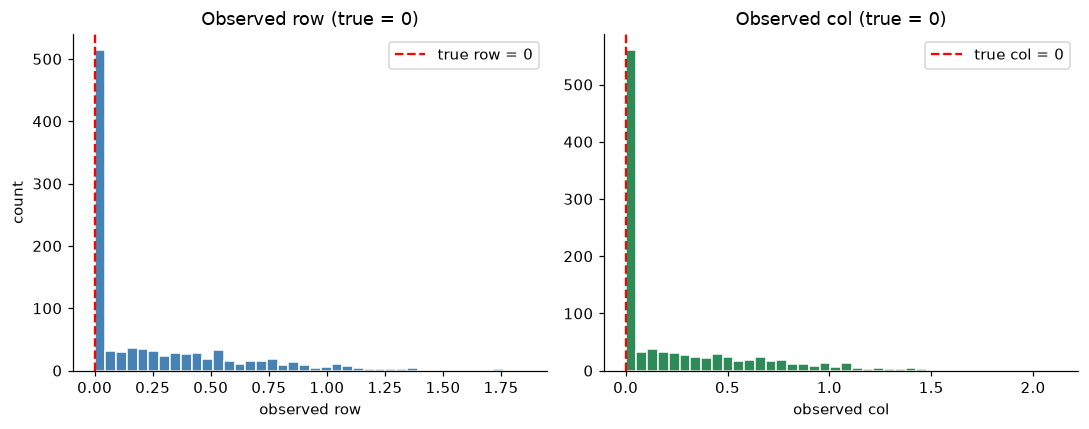

True position: (0, 0)
Mean observed: (0.240, 0.228)
Std  observed: (0.345,  0.345)


In [9]:
env = GridWorldEnv(size=5, observation_noise=0.15)

observed_rows = []
observed_cols = []

for seed in range(1000):
    obs, _ = env.reset(seed=seed)
    observed_rows.append(obs[0] * (env.size - 1))  # un-normalize
    observed_cols.append(obs[1] * (env.size - 1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(observed_rows, bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", label="true row = 0")
axes[0].set_title("Observed row (true = 0)")
axes[0].set_xlabel("observed row")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].hist(observed_cols, bins=40, color="seagreen", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", label="true col = 0")
axes[1].set_title("Observed col (true = 0)")
axes[1].set_xlabel("observed col")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"True position: (0, 0)")
print(f"Mean observed: ({np.mean(observed_rows):.3f}, {np.mean(observed_cols):.3f})")
print(f"Std  observed: ({np.std(observed_rows):.3f},  {np.std(observed_cols):.3f})")

## 5. Reward noise: the reward signal is perturbed

With `reward_noise > 0`, the reward returned to the agent is jittered by Gaussian noise. The true reward is still +1.0 at the goal, but the agent sees a slightly different value each time.

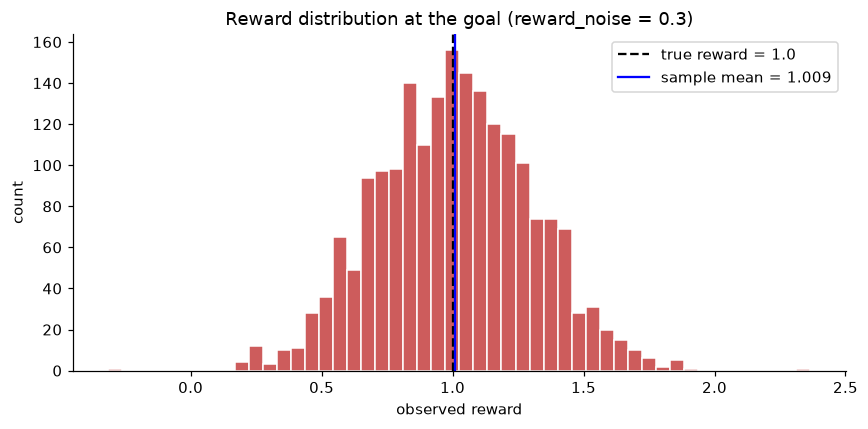

True reward:    1.000
Sample mean:    1.009
Sample std:     0.295


In [10]:
# Small env where goal is one step right of start.
env = GridWorldEnv(size=3, goal=(0, 1), goal_reward=1.0, reward_noise=0.3)

rewards = []
for seed in range(2000):
    env.reset(seed=seed)
    _, reward, terminated, _, _ = env.step(1)  # right into goal
    assert terminated
    rewards.append(reward)

rewards = np.array(rewards)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rewards, bins=50, color="indianred", edgecolor="white")
ax.axvline(1.0, color="black", linestyle="--", label="true reward = 1.0")
ax.axvline(rewards.mean(), color="blue", linestyle="-", label=f"sample mean = {rewards.mean():.3f}")
ax.set_title("Reward distribution at the goal (reward_noise = 0.3)")
ax.set_xlabel("observed reward")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"True reward:    1.000")
print(f"Sample mean:    {rewards.mean():.3f}")
print(f"Sample std:     {rewards.std():.3f}")

## 6. RGB rendering: see the grid as an image

We render the gridworld as an RGB numpy array, so we can display it directly with matplotlib. This also shows the obstacles and penalty states in action.

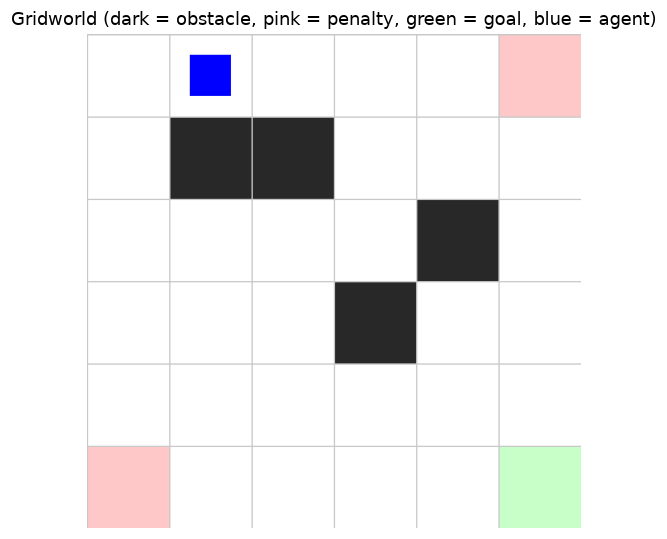

In [11]:
env = GridWorldEnv(
    size=6,
    obstacles=[(1, 1), (1, 2), (3, 3), (2, 4)],
    penalty_states=[(0, 5), (5, 0)],
    render_mode="rgb_array",
)
env.reset(seed=0)
env.step(1)   # move right
env.step(2)   # move down

frame = env.render()

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(frame)
ax.set_title("Gridworld (dark = obstacle, pink = penalty, green = goal, blue = agent)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 7. A fuller trajectory through the grid

We run an agent that always moves toward the goal (a simple hand-coded policy) and record its trajectory. This shows what a "successful" episode looks like end to end.

Episode length:    10
Total reward:      1.00
Final position:    (np.int64(5), np.int64(5))
Goal position:     (np.int64(5), np.int64(5))
Reached goal:      True


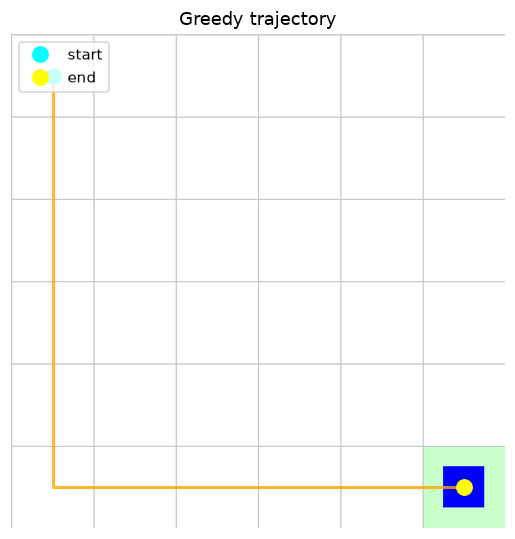

In [12]:
env = GridWorldEnv(size=6, render_mode="rgb_array")

def hand_coded_action(pos, goal):
    """Move toward the goal greedily (down first, then right)."""
    dr = goal[0] - pos[0]
    dc = goal[1] - pos[1]
    if dr > 0:
        return 2   # down
    if dc > 0:
        return 1   # right
    return 0

env.reset(seed=0)
positions = [env._agent_pos.copy()]
actions = []
rewards = []

for _ in range(50):
    action = hand_coded_action(env._agent_pos, env.goal)
    _, reward, terminated, truncated, info = env.step(action)
    positions.append(env._agent_pos.copy())
    actions.append(action)
    rewards.append(reward)
    if terminated or truncated:
        break

print(f"Episode length:    {len(actions)}")
print(f"Total reward:      {sum(rewards):.2f}")
print(f"Final position:    {tuple(positions[-1])}")
print(f"Goal position:     {tuple(env.goal)}")
print(f"Reached goal:      {np.array_equal(positions[-1], env.goal)}")

# Plot the trajectory on the grid.
frame = env.render()
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(frame)

# Overlay the path.
cell = frame.shape[0] // env.size
xs = [(p[1] + 0.5) * cell for p in positions]
ys = [(p[0] + 0.5) * cell for p in positions]
ax.plot(xs, ys, "-", color="orange", linewidth=2, alpha=0.8)
ax.plot(xs[0], ys[0], "o", color="cyan", markersize=10, label="start")
ax.plot(xs[-1], ys[-1], "o", color="yellow", markersize=10, label="end")
ax.set_title("Greedy trajectory")
ax.legend(loc="upper left")
ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Reproducibility check

One of the most important properties of a research environment: the same seed produces the same trajectory. We run the same seed twice with high noise, and confirm the outputs are identical.

In [13]:
def run_episode(env, seed, n_steps=10):
    obs, _ = env.reset(seed=seed)
    trajectory = [obs.copy()]
    rewards = []
    rng = np.random.default_rng(seed)  # deterministic action sequence
    for _ in range(n_steps):
        action = int(rng.integers(0, 4))
        obs, reward, terminated, truncated, _ = env.step(action)
        trajectory.append(obs.copy())
        rewards.append(reward)
        if terminated or truncated:
            break
    return trajectory, rewards

env = GridWorldEnv(size=5, transition_noise=0.5, observation_noise=0.1, reward_noise=0.2)

traj_a, rew_a = run_episode(env, seed=42)
traj_b, rew_b = run_episode(env, seed=42)

same_obs = all(np.array_equal(a, b) for a, b in zip(traj_a, traj_b))
same_rewards = rew_a == rew_b

print(f"Same observations across runs: {same_obs}")
print(f"Same rewards across runs:      {same_rewards}")

# Now a different seed to show it produces different results.
traj_c, rew_c = run_episode(env, seed=43)
diff_from_a = any(not np.array_equal(a, c) for a, c in zip(traj_a, traj_c))
print(f"Different seed produces different trajectory: {diff_from_a}")

Same observations across runs: True
Same rewards across runs:      True
Different seed produces different trajectory: True


## 9. Combined noise: what the agent will actually face

The experiments in this project will train agents under combined noise (transition + observation + reward). Let's visualize how performance of a hand-coded policy degrades as noise increases.

noise=0.0 | success_rate=1.000 | mean_reward=+1.000
noise=0.2 | success_rate=1.000 | mean_reward=+1.060
noise=0.4 | success_rate=1.000 | mean_reward=+1.044
noise=0.6 | success_rate=0.955 | mean_reward=+0.801
noise=0.8 | success_rate=0.425 | mean_reward=+0.106


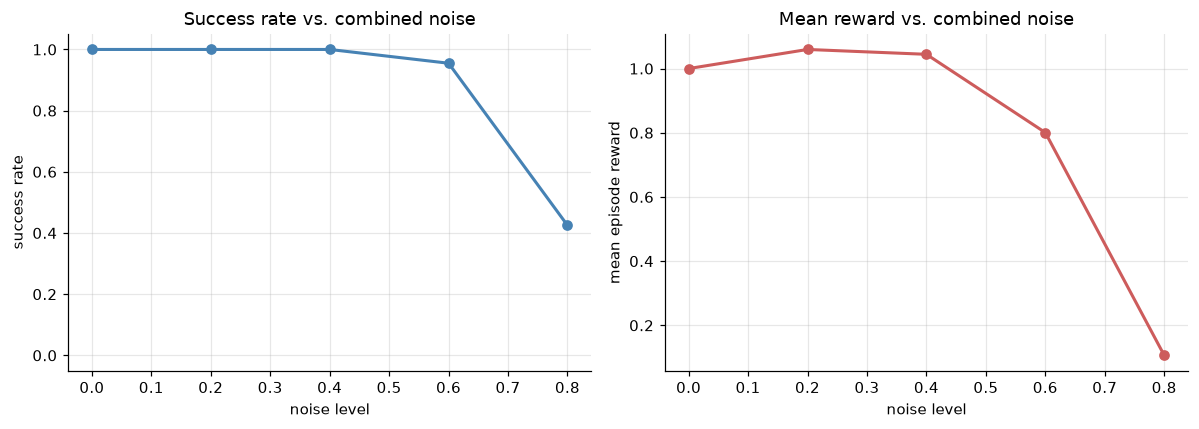

In [14]:
def greedy_policy(pos, goal):
    dr = goal[0] - pos[0]
    dc = goal[1] - pos[1]
    if abs(dr) > abs(dc):
        return 2 if dr > 0 else 0
    return 1 if dc > 0 else 3

def evaluate(transition_noise, observation_noise, reward_noise, n_episodes=100):
    env = GridWorldEnv(
        size=6,
        transition_noise=transition_noise,
        observation_noise=observation_noise,
        reward_noise=reward_noise,
        max_steps=50,
    )
    successes = 0
    total_rewards = []
    for seed in range(n_episodes):
        env.reset(seed=seed)
        episode_reward = 0.0
        for _ in range(50):
            action = greedy_policy(env._agent_pos, env.goal)
            _, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward
            if terminated:
                successes += 1
                break
            if truncated:
                break
        total_rewards.append(episode_reward)
    return successes / n_episodes, float(np.mean(total_rewards))

noise_levels = [0.0, 0.2, 0.4, 0.6, 0.8]
success_rates = []
mean_rewards = []

for n in noise_levels:
    sr, mr = evaluate(n, n, n, n_episodes=200)
    success_rates.append(sr)
    mean_rewards.append(mr)
    print(f"noise={n:.1f} | success_rate={sr:.3f} | mean_reward={mr:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(noise_levels, success_rates, "o-", color="steelblue", linewidth=2)
axes[0].set_title("Success rate vs. combined noise")
axes[0].set_xlabel("noise level")
axes[0].set_ylabel("success rate")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)

axes[1].plot(noise_levels, mean_rewards, "o-", color="indianred", linewidth=2)
axes[1].set_title("Mean reward vs. combined noise")
axes[1].set_xlabel("noise level")
axes[1].set_ylabel("mean episode reward")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

We've verified that:

1. The environment moves the agent correctly and reports state/termination properly.
2. Transition noise causes perpendicular slips (not random actions), at the configured frequency.
3. Observation noise perturbs the state vector around the true position.
4. Reward noise jitters the reward signal around the true reward.
5. RGB rendering works and shows obstacles/penalties/goal clearly.
6. Seeded runs are exactly reproducible.
7. Under combined noise, a hand-coded greedy policy's performance degrades.

**Next steps:** build the LIF neuron wrapper, the eligibility trace module, the R-STDP learning rule, and the actor-critic agent. Notebook 02_first_training_run.ipynb trains the complete pipeline on this environment.